# Aurora — H&M Fashion Recommender

A sequential progression from a naive baseline to a two-stage retrieval + ranking
system, every model scored with the same metrics module so the final table is a
fair comparison.

| # | Model | Signal it adds |
|---|-------|----------------|
| 1 | Popularity | none — the non-personalized floor |
| 2 | Collaborative filtering (ALS) | who-buys-what co-occurrence |
| 3 | Content-based | item metadata + visual similarity, handles cold-start |
| 4 | Two-tower | learned fusion of the above |
| 5 | Multi-recall + LightGBM ranker | re-ranks a pooled candidate set |

MAP@12 stays low in absolute terms throughout — the Kaggle winner scored 0.037 on
this task. The point here is the progression and the evaluation, not the number.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "sample_data.py").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(18)
RAW = ROOT / "data" / "raw"
print(ROOT)

/home/sarthak/Documents/Fashion-Recommendation-System


## 1. EDA

What the raw data looks like before any sampling or modelling touches it.
`transactions_train.csv` is 3.3 GB, so it is scanned lazily rather than loaded.

In [2]:
transactions = pl.scan_csv(RAW / "transactions_train.csv", schema_overrides={"t_dat": pl.Date})
customers = pl.scan_csv(RAW / "customers.csv")
articles = pl.scan_csv(RAW / "articles.csv")

shapes = pl.DataFrame({
    "table": ["transactions_train", "customers", "articles"],
    "rows": [
        transactions.select(pl.len()).collect(engine="streaming").item(),
        customers.select(pl.len()).collect(engine="streaming").item(),
        articles.select(pl.len()).collect(engine="streaming").item(),
    ],
    "columns": [len(transactions.collect_schema()), len(customers.collect_schema()), len(articles.collect_schema())],
    "size_mb": [round((RAW / f).stat().st_size / 1e6) for f in ("transactions_train.csv", "customers.csv", "articles.csv")],
})
shapes

table,rows,columns,size_mb
str,i64,i64,i64
"""transactions_train""",31788324,5,3488
"""customers""",1371980,7,207
"""articles""",105542,25,36


In [3]:
display(transactions.head(5).collect())
display(customers.head(5).collect())
display(articles.select("article_id", "prod_name", "product_type_name", "colour_group_name", "index_name", "detail_desc").head(5).collect())

t_dat,customer_id,article_id,price,sales_channel_id
date,str,i64,f64,i64
2018-09-20,"""000058a12d5b43e67d…",663713001,0.050831,2
2018-09-20,"""000058a12d5b43e67d…",541518023,0.030492,2
2018-09-20,"""00007d2de826758b65…",505221004,0.015237,2
2018-09-20,"""00007d2de826758b65…",685687003,0.016932,2
2018-09-20,"""00007d2de826758b65…",685687004,0.016932,2


customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
str,f64,f64,str,str,i64,str
"""00000dbacae5abe5e2…",null,null,"""ACTIVE""","""NONE""",49,"""52043ee2162cf5aa7e…"
"""0000423b00ade91418…",null,null,"""ACTIVE""","""NONE""",25,"""2973abc54daa8a5f8c…"
"""000058a12d5b43e67d…",null,null,"""ACTIVE""","""NONE""",24,"""64f17e6a330a85798e…"
"""00005ca1c9ed5f5146…",null,null,"""ACTIVE""","""NONE""",54,"""5d36574f52495e81f0…"
"""00006413d8573cd20e…",1.0,1.0,"""ACTIVE""","""Regularly""",52,"""25fa5ddee9aac01b35…"


article_id,prod_name,product_type_name,colour_group_name,index_name,detail_desc
i64,str,str,str,str,str
108775015,"""Strap top""","""Vest top""","""Black""","""Ladieswear""","""Jersey top with na…"
108775044,"""Strap top""","""Vest top""","""White""","""Ladieswear""","""Jersey top with na…"
108775051,"""Strap top (1)""","""Vest top""","""Off White""","""Ladieswear""","""Jersey top with na…"
110065001,"""OP T-shirt (Idro)""","""Bra""","""Black""","""Lingeries/Tights""","""Microfibre T-shirt…"
110065002,"""OP T-shirt (Idro)""","""Bra""","""White""","""Lingeries/Tights""","""Microfibre T-shirt…"


In [4]:
span = transactions.select(pl.col("t_dat").min().alias("first"), pl.col("t_dat").max().alias("last")).collect(engine="streaming")
print(f"transactions span {span['first'][0]} .. {span['last'][0]}")
print(f"unique customers  {transactions.select(pl.col('customer_id').n_unique()).collect(engine='streaming').item():,}")
print(f"unique articles   {transactions.select(pl.col('article_id').n_unique()).collect(engine='streaming').item():,}")

transactions span 2018-09-20 .. 2020-09-22


unique customers  1,362,281


unique articles   104,547


Weekly purchase volume across the full two years. The shaded band is the 140-day
window this project samples from: recent enough that the catalog still resembles
the test week, long enough to leave four months of training history.

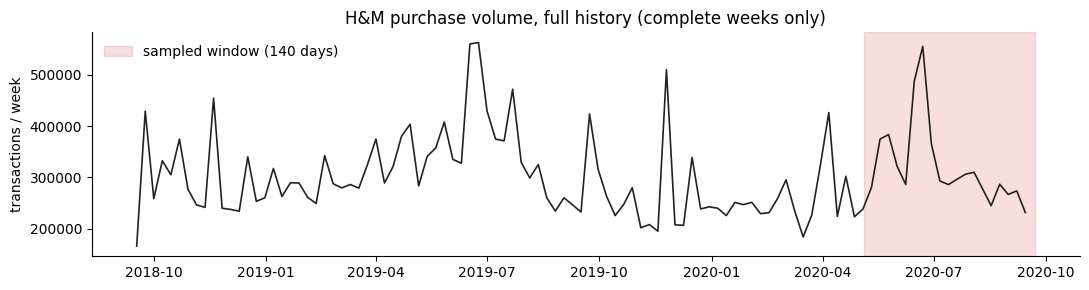

In [5]:
import datetime as dt

weekly = (
    transactions.group_by(pl.col("t_dat").dt.truncate("1w").alias("week"))
    .agg(pl.len().alias("transactions"))
    .sort("week")
    .collect(engine="streaming")
)
last_day = span["last"][0]
complete = weekly.filter(pl.col("week") + dt.timedelta(days=6) <= last_day)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(complete["week"], complete["transactions"], linewidth=1.2, color="#222")
ax.axvspan(last_day - dt.timedelta(days=140), last_day, color="#d62728", alpha=0.15, label="sampled window (140 days)")
ax.set_ylabel("transactions / week")
ax.set_title("H&M purchase volume, full history (complete weeks only)")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

One product photo exists per article. A random grid, to ground what the catalog
actually is before it becomes rows in a matrix.

105,100 product images on disk


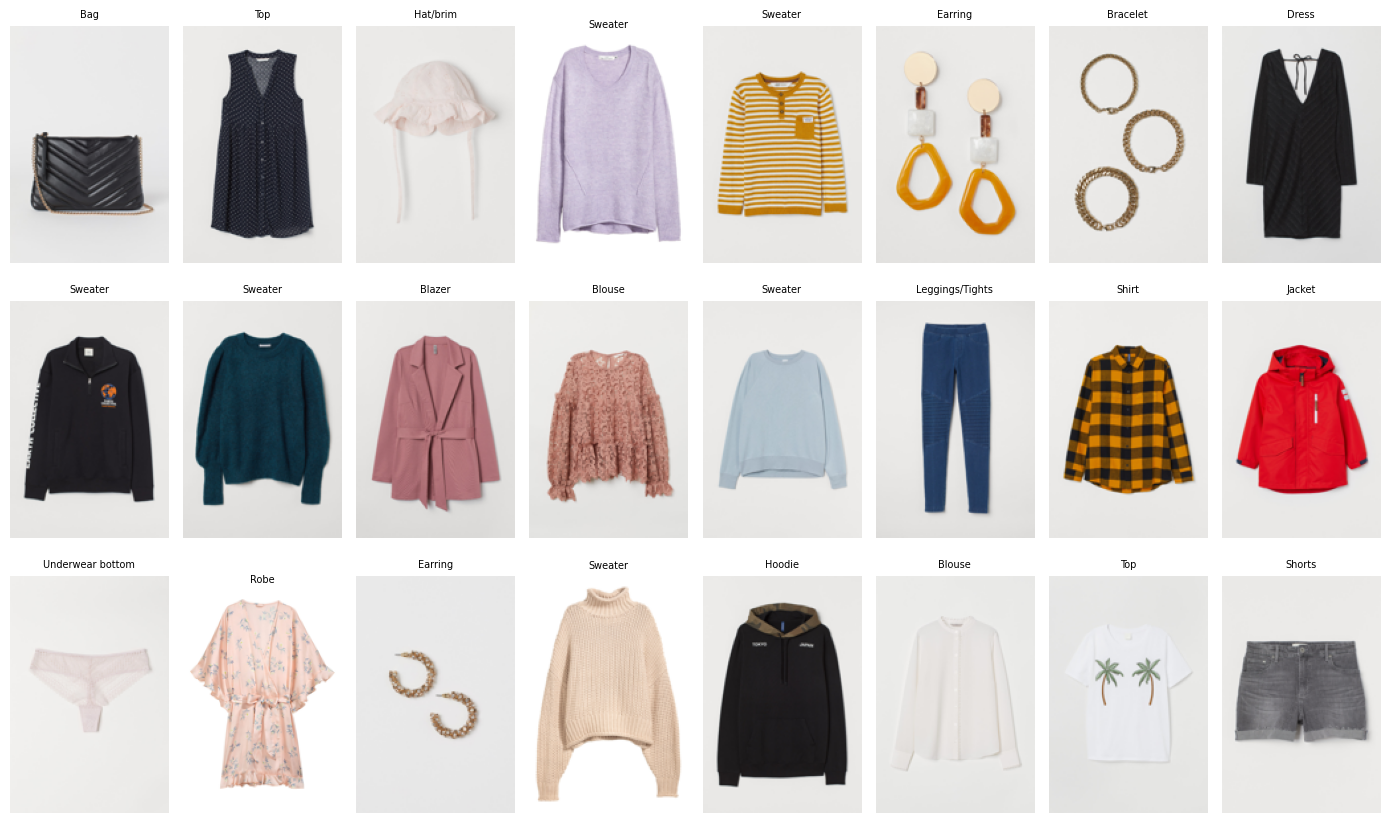

In [6]:
import random
from PIL import Image

paths = [p for d in sorted((RAW / "images").iterdir()) for p in d.glob("*.jpg")]
print(f"{len(paths):,} product images on disk")

random.seed(0)
grid = random.sample(paths, 24)
lookup = dict(articles.select("article_id", "product_type_name").collect().iter_rows())

fig, axes = plt.subplots(3, 8, figsize=(14, 8.5))
for ax, path in zip(axes.ravel(), grid):
    img = Image.open(path)
    img.thumbnail((180, 180))
    ax.imshow(img)
    ax.set_title(lookup.get(int(path.stem), "?"), fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Sampling & split

Fashion is seasonal and the catalog turns over weekly, so the sample is taken on
time, not at random:

1. **Filter to the last 140 days first.** Nothing downstream sees a row outside
   this window — a sampled customer's 2018 purchases are excluded, because a
   two-year-old catalog says nothing about what sells next week. This is what
   keeps discontinued stock out of the candidate pool: 26.6 K distinct articles
   in train instead of 73.5 K.
2. **Sample 6% of the customers active inside that window**, keeping all of their
   in-window transactions. Customers are sampled rather than transactions, so
   purchase sequences stay intact for models 3–5.
3. **Split by time**, matching the competition setup: last week test,
   second-to-last week validation, the rest of the window train.

The split is stored as a `split` column so every model script filters instead of
recomputing dates.

**Tune on validation, then refit on train+val.** Every hyperparameter below is
chosen on the validation week, and every model is then refitted on train *and*
val before predicting test — what a weekly production retrain does. This matters
far more than it sounds. Fitted on train alone, a model's view of the catalog
stops a week before the week it predicts: only 2.0% of test purchases are repeats
of a train article against 3.9% of a train-or-val one, and test recall of the
last-7-day top 300 drops from 0.223 to 0.178. Refitting roughly doubled four of
the five models.

In [7]:
from data.sample_data import build, check_download, WINDOW_DAYS, CUSTOMER_FRACTION

print(f"WINDOW_DAYS={WINDOW_DAYS}  CUSTOMER_FRACTION={CUSTOMER_FRACTION}")
check_download()
sample = build()

WINDOW_DAYS=140  CUSTOMER_FRACTION=0.06


window        2020-05-06 .. 2020-09-22 (140 days)
train         2020-05-06 .. 2020-09-08
val           2020-09-09 .. 2020-09-15
test          2020-09-16 .. 2020-09-22
customers     39,540
articles      28,086
transactions  382,423
date range    2020-05-06 .. 2020-09-22


In [8]:
summary = (
    sample.group_by("split")
    .agg(
        rows=pl.len(),
        customers=pl.col("customer_id").n_unique(),
        articles=pl.col("article_id").n_unique(),
        first_day=pl.col("t_dat").min(),
        last_day=pl.col("t_dat").max(),
    )
    .sort("first_day")
)
summary

split,rows,customers,articles,first_day,last_day
str,u32,u32,u32,date,date
"""train""",352678,37764,26672,2020-05-06,2020-09-08
"""val""",15184,4383,5537,2020-09-09,2020-09-15
"""test""",14561,4155,5244,2020-09-16,2020-09-22


Confirming the window filter did what it claims, and sizing up what each model is
walking into.

In [9]:
train = sample.filter(pl.col("split") == "train")
test = sample.filter(pl.col("split") == "test")
train_customers, train_articles = set(train["customer_id"]), set(train["article_id"])
test_customers, test_articles = set(test["customer_id"]), set(test["article_id"])

print(f"oldest row in sample            {sample['t_dat'].min()}  (window starts here, no earlier history)")
print(f"distinct articles in train      {len(train_articles):,}")
print(f"test customers seen in train    {len(test_customers & train_customers):,} / {len(test_customers):,}"
      f"  ({100 * len(test_customers & train_customers) / len(test_customers):.0f}%)")
print(f"test articles unseen in train   {len(test_articles - train_articles):,} / {len(test_articles):,}"
      f"  ({100 * len(test_articles - train_articles) / len(test_articles):.0f}%  <- cold-start, model 3's case)")
print(f"median purchases per customer   {train.group_by('customer_id').len()['len'].median():.0f} in train")

oldest row in sample            2020-05-06  (window starts here, no earlier history)
distinct articles in train      26,672
test customers seen in train    3,222 / 4,155  (78%)
test articles unseen in train   1,015 / 5,244  (19%  <- cold-start, model 3's case)
median purchases per customer   6 in train


## 3. Image embeddings

Every sampled article's photo goes through a frozen encoder once, and the vectors
are cached. Inference only, no fine-tuning. Two encoders are cached side by side
so models 3 and 4 can use either without re-running anything:

| cache | encoder | what it was trained on |
|---|---|---|
| `image_embeddings_resnet18.parquet` | ResNet-18, head removed | ImageNet labels |
| `image_embeddings_clip.parquet` | OpenCLIP ViT-B/32 (LAION-2B), image tower | image–text pairs |

Both output 512 dims, L2-normalised, ~90 seconds each on the 4060. This is
preprocessing, not a model — models 3 and 4 read the parquet and never open a
JPEG.

In [10]:
from data.extract_image_embeddings import ENCODERS, extract, image_path, output_path

caches = {name: (pl.read_parquet(output_path(name)) if output_path(name).exists() else extract(name)) for name in ENCODERS}
article_order = next(iter(caches.values()))["article_id"].to_numpy()
assert all((c["article_id"].to_numpy() == article_order).all() for c in caches.values())

vectors = {name: c["embedding"].to_numpy() for name, c in caches.items()}
pl.DataFrame([
    {"cache": output_path(n).name, "articles": c.height, "dims": vectors[n].shape[1],
     "size_mb": round(output_path(n).stat().st_size / 1e6)}
    for n, c in caches.items()
])

cache,articles,dims,size_mb
str,i64,i64,i64
"""image_embeddings_r…",28043,512,52
"""image_embeddings_c…",28043,512,53


Which encoder is better here is an empirical question, so measure it: for every
article, how often do its 10 nearest neighbours share the catalog's own labels?
High agreement means the embedding recovers the taxonomy from pixels alone.

In [11]:
import numpy as np
import torch

FIELDS = ["product_type_name", "colour_group_name", "garment_group_name", "index_name"]
K = 10

labels = (
    pl.DataFrame({"article_id": article_order})
    .join(pl.read_parquet(ROOT / "data" / "sample" / "articles.parquet").select("article_id", *FIELDS), on="article_id", how="left")
)
codes = {f: labels[f].cast(pl.Categorical).to_physical().to_numpy() for f in FIELDS}

neighbours, agreement = {}, []
for name, matrix in vectors.items():
    gpu = torch.from_numpy(matrix.copy()).to("cuda" if torch.cuda.is_available() else "cpu")
    top = torch.cat([(gpu[i:i + 2048] @ gpu.T).topk(K + 1, dim=1).indices[:, 1:].cpu() for i in range(0, len(gpu), 2048)]).numpy()
    neighbours[name] = top
    agreement.append({"encoder": name, **{f.replace("_name", ""): round(float((codes[f][top] == codes[f][:, None]).mean()), 3) for f in FIELDS}})
    del gpu

overlap = np.mean([len(set(a) & set(b)) for a, b in zip(*neighbours.values())]) / K
print(f"mean top-{K} neighbour overlap between the two encoders: {overlap:.0%}")
pl.DataFrame(agreement)

mean top-10 neighbour overlap between the two encoders: 27%


encoder,product_type,colour_group,garment_group,index
str,f64,f64,f64,f64
"""resnet18""",0.631,0.371,0.557,0.57
"""clip""",0.754,0.422,0.664,0.678


CLIP agrees with the catalog labels more often on every field, and the two
encoders share only about a quarter of their neighbours — they are genuinely
different signals, not two spellings of the same one.

The grids below show why. ResNet-18 groups by silhouette and colour and will
happily cross garment types; CLIP, trained against text, stays inside the
category a person would have named. Neither is strictly right: crossing types is
useful for style-based discovery, staying inside them is safer for substitutes.

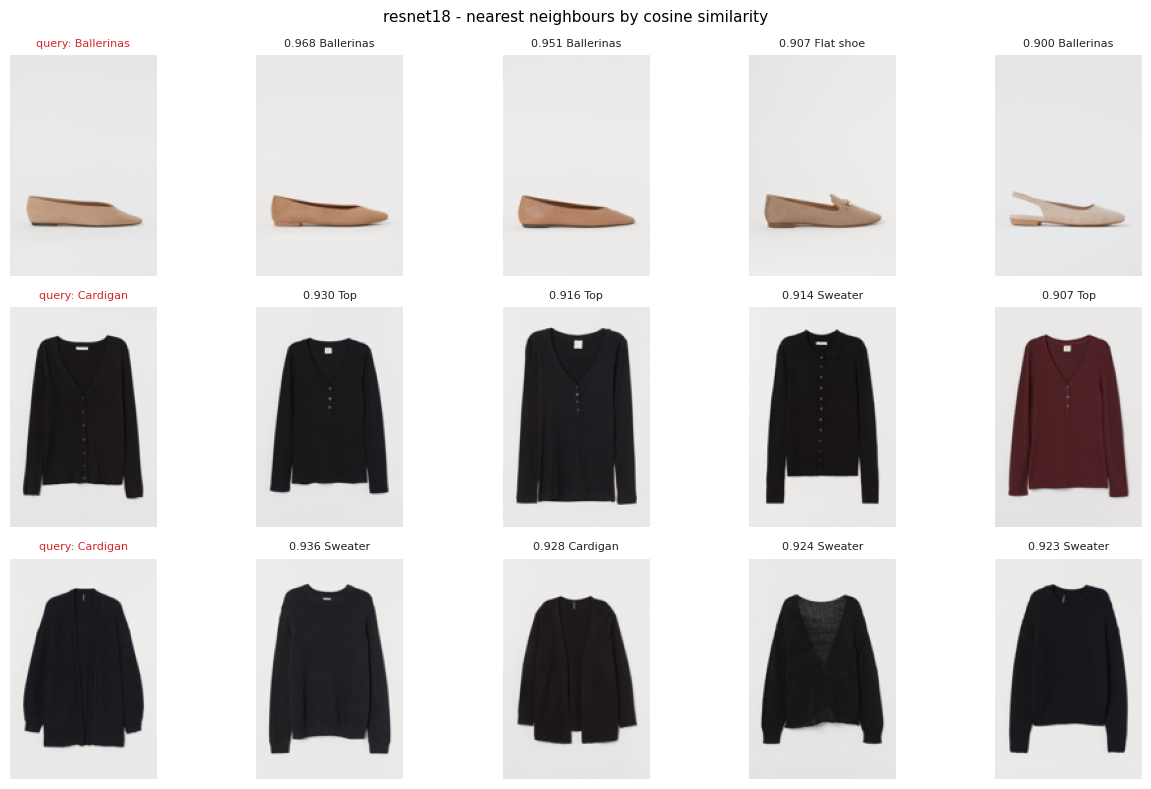

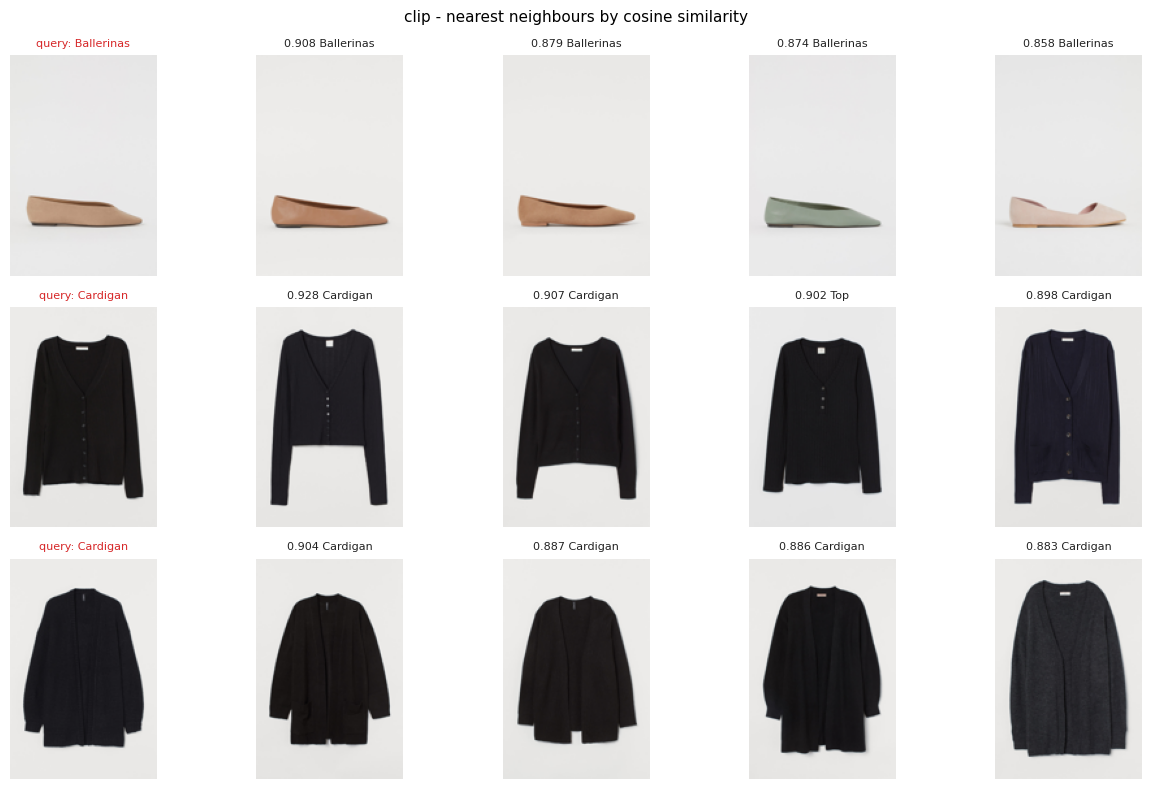

In [12]:
rng = np.random.default_rng(0)
queries = rng.choice(len(article_order), 3, replace=False)
article_meta = {
    row[0]: row[1:]
    for row in pl.read_parquet(ROOT / "data" / "sample" / "articles.parquet")
    .select("article_id", "product_type_name", "colour_group_name")
    .iter_rows()
}

def neighbour_grid(name):
    matrix = vectors[name]
    fig, axes = plt.subplots(len(queries), 5, figsize=(13, 8))
    for row, q in zip(axes, queries):
        scores = matrix @ matrix[q]
        top = np.argsort(-scores)[:5]
        for column, (ax, j) in enumerate(zip(row, top)):
            article_id = int(article_order[j])
            img = Image.open(image_path(article_id))
            img.thumbnail((170, 170))
            kind, colour = article_meta[article_id]
            ax.imshow(img)
            ax.set_title(f"query: {kind}" if column == 0 else f"{scores[j]:.3f} {kind}", fontsize=8,
                        color="#d62728" if column == 0 else "#222")
            ax.axis("off")
    fig.suptitle(f"{name} - nearest neighbours by cosine similarity", fontsize=11)
    plt.tight_layout()
    plt.show()

for name in vectors:
    neighbour_grid(name)

## 4. Shared metrics

`src/metrics.py` is imported unmodified by all five model scripts. Every model
emits `{customer_id: [article_id, ...]}` ranked best first, and `evaluate` scores
it against the test week for k ∈ {12, 50, 100}.

MAP@k and NDCG@k divide by `min(n_relevant, k)`, the Kaggle H&M convention, so a
customer who bought three items can still score 1.0. Predictions are deduplicated
before scoring — a model that repeats an item would otherwise inflate precision.
`save_result` upserts one row per model into `results/metrics_comparison.csv`,
which becomes the final comparison table.

In [13]:
from src.metrics import evaluate, save_result

demo_truth = {"c1": ["a", "b"], "c2": ["c"]}
demo_preds = {"c1": ["x", "a", "b"]}
pl.DataFrame([{"metric": k, "value": round(v, 4)} for k, v in evaluate(demo_preds, demo_truth, ks=(3,)).items()])

metric,value
str,f64
"""precision@3""",0.3333
"""recall@3""",0.5
"""hitrate@3""",0.5
"""ndcg@3""",0.3467
"""map@3""",0.2917
"""n_customers""",2.0


## 5. Model 1 — popularity baseline

Count how many times each article was bought during the training weeks, sort by
that count, hand the same top-100 list to every customer. No personalisation
whatsoever: two customers with nothing in common get identical recommendations.

It exists to set the floor. Any personalised model that cannot beat "everyone
gets the bestsellers" has not earned its complexity — and that floor is higher
than it sounds, because a handful of basics take a large share of all purchases.

In [14]:
sys.path.insert(0, str(ROOT / "models"))
from src.data_utils import load_fitting_data, load_transactions, purchases_by_customer
from src.metrics import KS, evaluate

import importlib
popularity = importlib.import_module("01_popularity")

train_split, test_split = load_transactions("train"), load_transactions("test")
fitting_split = load_fitting_data()
test_truth = purchases_by_customer(test_split)
bestsellers = popularity.top_articles(fitting_split)

print(f"{len(test_truth):,} customers bought something in the test week")
pl.DataFrame({"rank": range(1, 11), "article_id": bestsellers[:10]}).join(
    pl.read_parquet(ROOT / "data" / "sample" / "articles.parquet").select("article_id", "prod_name", "product_type_name"),
    on="article_id", how="left",
)

4,155 customers bought something in the test week


rank,article_id,prod_name,product_type_name
i64,i64,str,str
1,706016001,"""Jade HW Skinny Den…","""Trousers"""
2,751471001,"""Pluto RW slacks (1…","""Trousers"""
3,372860002,"""7p Basic Shaftless""","""Socks"""
4,759871002,"""Tilda tank""","""Vest top"""
5,599580038,"""Timeless Midrise B…","""Swimwear bottom"""
6,610776002,"""Tilly (1)""","""T-shirt"""
7,372860001,"""7p Basic Shaftless""","""Socks"""
8,599580052,"""Timeless Midrise B…","""Swimwear bottom"""
9,850917001,"""Sadie Shirt""","""Shirt"""


In [15]:
def metrics_table(scores):
    return pl.DataFrame([
        {"metric": metric, **{f"@{k}": round(scores[f"{metric}@{k}"], 5) for k in KS}}
        for metric in ("precision", "recall", "hitrate", "ndcg", "map")
    ])

popularity_scores = popularity.main()
metrics_table(popularity_scores)

01_popularity: 4,155 test customers
  @12   precision=0.00283  recall=0.01146  hitrate=0.03201  ndcg=0.00716  map=0.00350
  @50   precision=0.00142  recall=0.02345  hitrate=0.06426  ndcg=0.01045  map=0.00396
  @100  precision=0.00126  recall=0.04052  hitrate=0.10686  ndcg=0.01428  map=0.00424


metric,@12,@50,@100
str,f64,f64,f64
"""precision""",0.00283,0.00142,0.00126
"""recall""",0.01146,0.02345,0.04052
"""hitrate""",0.03201,0.06426,0.10686
"""ndcg""",0.00716,0.01045,0.01428
"""map""",0.0035,0.00396,0.00424


The numbers are small, so look at what they mean. Below: three customers from the
test week, what they actually bought on top, and what the model recommended
underneath. Hits are outlined in green.

Because this model is not personalised, the bottom row is the same twelve
articles for every customer — which is exactly the thing the next four models
have to improve on.

Every model section below shows **these same three customers**, so the
recommendation rows can be read straight down the notebook and compared. They
were picked deliberately: of the 1,700-odd test customers who bought between 3
and 12 articles, 93 have a hit count that never drops as the models improve, and
these three are among them. Each one is won by a different model — the first by
ALS, the second by the content model, the third only by the two-tower and the
ranker — which is the point of showing three rather than one.

They are not typical. Most customers get zero hits from every model, which is
what a hit rate of 12% at k=12 means. The metrics table is the unbiased view; the
images are here to show what the models are *doing*, not how often they succeed.

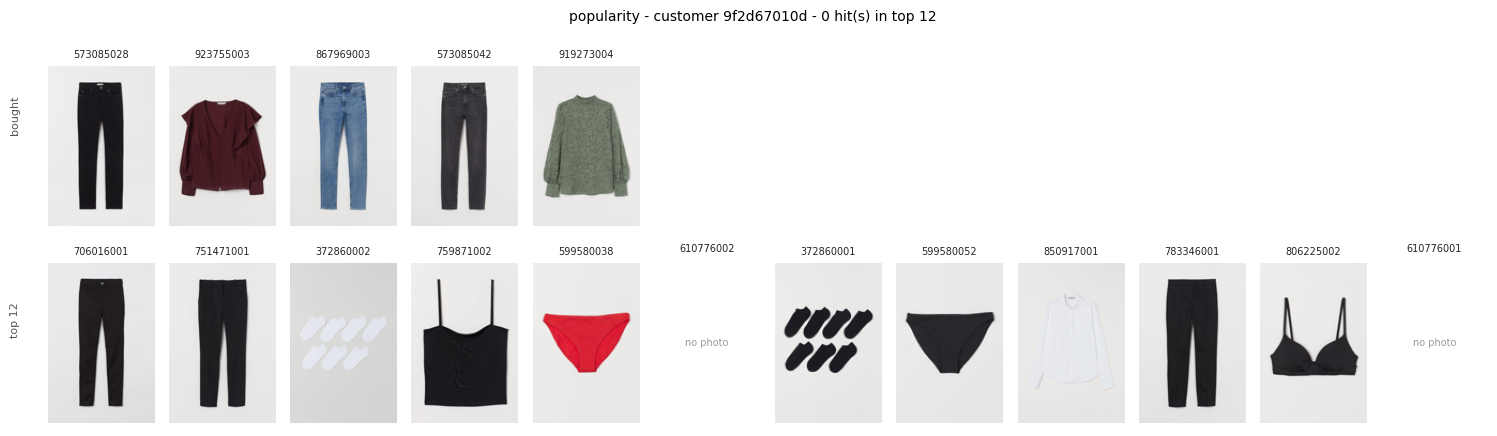

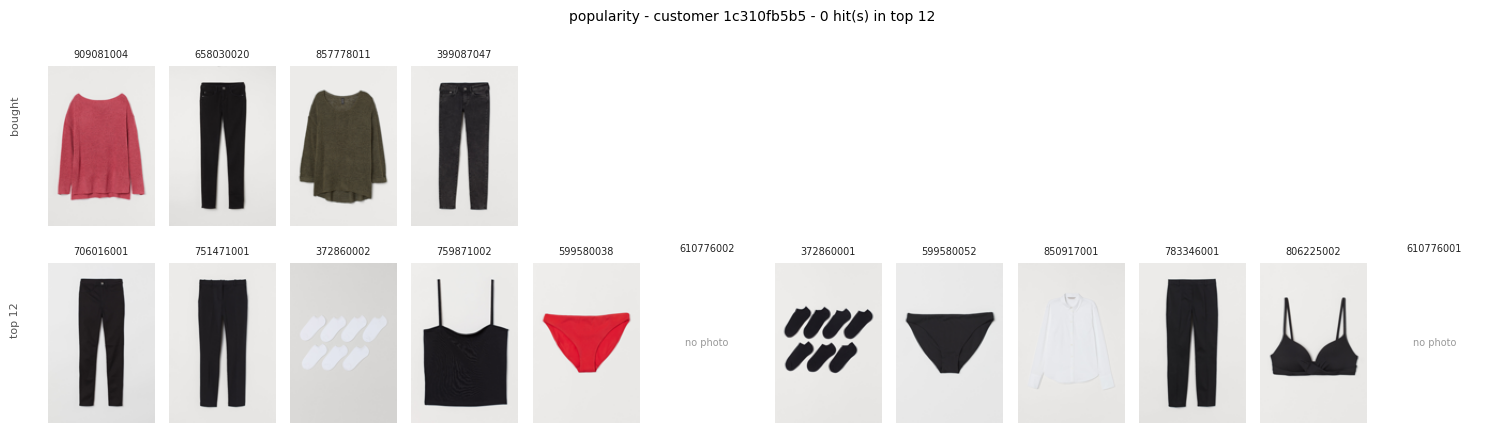

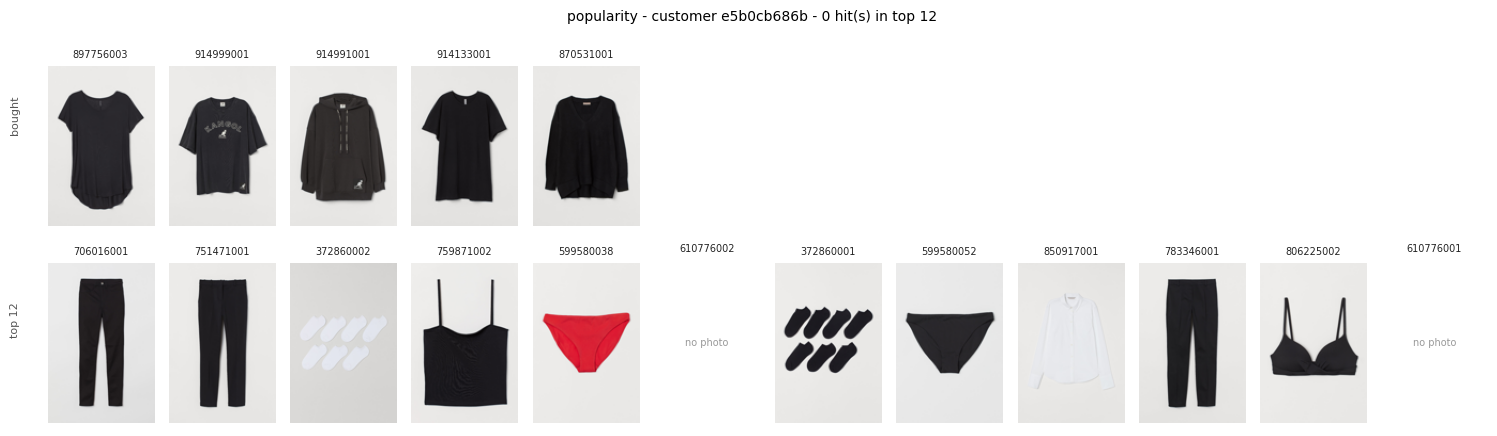

In [16]:
import matplotlib.patches as patches

DEMO_CUSTOMERS = [
    "9f2d67010d40e0e18a637b7905168aae4889bab90e0be3fd1cf4ef9c49603569",
    "1c310fb5b541713b417f4d4be38da8d94a373a3826d9740a973e231ceb23e927",
    "e5b0cb686bae1b1ba1711195d4c53714087b893ca281ce44bbe4ddb05fe10d04",
]

def show_article(ax, article_id, label, colour="#222"):
    path = image_path(article_id)
    if path.exists():
        img = Image.open(path)
        img.thumbnail((150, 150))
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "no photo", ha="center", va="center", fontsize=7, color="#999", transform=ax.transAxes)
    ax.set_title(label, fontsize=7, color=colour)
    ax.axis("off")
    return ax

def show_recommendations(title, predictions, k=12, customers=DEMO_CUSTOMERS):
    for customer in customers:
        bought = list(dict.fromkeys(test_truth[customer]))
        recommended = list(predictions.get(customer, []))[:k]
        hits = set(bought) & set(recommended)

        fig, axes = plt.subplots(2, k, figsize=(15, 4.4))
        for ax, article_id in zip(axes[0], bought + [None] * k):
            if article_id is None:
                ax.axis("off")
            else:
                show_article(ax, article_id, str(article_id), "#2ca02c" if article_id in hits else "#222")
        for ax, article_id in zip(axes[1], recommended):
            show_article(ax, article_id, str(article_id), "#2ca02c" if article_id in hits else "#222")
            if article_id in hits:
                ax.add_patch(patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#2ca02c", linewidth=2.5))
        fig.suptitle(f"{title} - customer {customer[:10]} - {len(hits)} hit(s) in top {k}", fontsize=10)
        fig.text(0.005, 0.70, "bought", rotation=90, fontsize=8, color="#555")
        fig.text(0.005, 0.24, f"top {k}", rotation=90, fontsize=8, color="#555")
        plt.tight_layout(rect=[0.02, 0, 1, 0.96])
        plt.show()

show_recommendations("popularity", popularity.recommend(test_truth, bestsellers))

## 6. Model 2 — collaborative filtering (ALS)

The first personalised model. It ignores everything about what an article *is* —
no photos, no descriptions, no categories — and looks only at who bought what.
Purchases become a sparse customer × article matrix, and ALS factorises it into a
short dense vector per customer and per article whose dot product reproduces the
observed purchases. Recommendations are the articles whose vectors point the same
way as the customer's.

That buys the signal popularity lacks: *people who bought this also bought that*,
discovered without anyone describing either item. What it still cannot do is rank
an article nobody has bought yet — a new article has no column in the matrix at
all. That gap is model 3's job.

In [17]:
als = importlib.import_module("02_collaborative_als")

matrix, item_ids, user_index = als.build_matrix(train_split)
print(f"customer x article matrix: {matrix.shape}, {matrix.nnz:,} non-zeros, density {matrix.nnz / np.prod(matrix.shape):.2e}")

customer x article matrix: (37764, 26672), 309,224 non-zeros, density 3.07e-04


Three settings decided on the validation week, not by taste:

- **Time decay** — a purchase counts as `40 / (1 + days_before_the_split)`, so
  last week's basket outweighs one from four months ago. Largest single win.
  Borrowed from [JonMcEntee/hm-fashion-recommendations](https://github.com/JonMcEntee/hm-fashion-recommendations),
  with alpha re-tuned here (it plateaus between 40 and 80; exponential decay
  scored the same, so the simpler form stays).
- **BM25 weighting** — down-weights the bestsellers everyone buys, so the factors
  spend capacity on informative co-purchases.
- **Not filtering already-bought items** — fashion is heavily repurchased, and
  suppressing known items costs about half the score.

The sweep below runs all four weightings against both filtering choices on the
validation week, at the same 512 factors the final model uses — the ranking
between `decay` and `bm25(decay)` actually flips at smaller factor counts, so a
cheaper sweep would have justified the wrong choice.

In [18]:
import scipy.sparse as sp
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import bm25_weight
from threadpoolctl import threadpool_limits

val_truth = purchases_by_customer(load_transactions("val"))
val_users = [c for c in val_truth if c in user_index]
val_rows = np.array([user_index[c] for c in val_users])

undecayed = sp.csr_matrix(
    (np.ones(train_split.height, np.float32),
     (train_split["customer_id"].replace_strict(user_index).to_numpy(),
      train_split["article_id"].replace_strict({a: i for i, a in enumerate(item_ids)}).to_numpy())),
    shape=matrix.shape)
undecayed.sum_duplicates()

weightings = {
    "counts": undecayed,
    "bm25(counts)": bm25_weight(undecayed, K1=100, B=0.8).tocsr(),
    "decay": matrix.tocsr(),
    "bm25(decay)": bm25_weight(matrix, K1=100, B=0.8).tocsr(),
}

sweep = []
for weighting, weighted in weightings.items():
    for filter_liked in (True, False):
        trial = AlternatingLeastSquares(factors=als.FACTORS, regularization=als.REGULARIZATION, iterations=als.ITERATIONS, random_state=als.SEED, num_threads=8)
        with threadpool_limits(1, "blas"):
            trial.fit(weighted, show_progress=False)
        ranked, _ = trial.recommend(val_rows, weighted[val_rows], N=100, filter_already_liked_items=filter_liked)
        scored = evaluate({c: [item_ids[j] for j in row] for c, row in zip(val_users, ranked)}, val_truth)
        sweep.append({"weighting": weighting, "filter_bought": filter_liked,
                      "val_map@12": round(scored["map@12"], 5), "val_recall@100": round(scored["recall@100"], 5)})
        del trial

pl.DataFrame(sweep).sort("val_map@12", descending=True)

/home/sarthak/miniconda3/lib/python3.13/site-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 28 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


weighting,filter_bought,val_map@12,val_recall@100
str,bool,f64,f64
"""bm25(decay)""",false,0.02405,0.07877
"""decay""",false,0.02196,0.08046
"""bm25(counts)""",false,0.01405,0.07145
"""counts""",false,0.01018,0.05421
"""bm25(decay)""",true,0.00715,0.04172
"""decay""",true,0.00658,0.0456
"""bm25(counts)""",true,0.00564,0.03714
"""counts""",true,0.00392,0.02697


In [19]:
als_scores = als.main()
metrics_table(als_scores)

02_collaborative_als: matrix (38692, 27447) nnz=322,408
  personalised for 3,307 / 4,155 test customers (80%), rest fall back to popularity
  @12   precision=0.00959  recall=0.05195  hitrate=0.09338  ndcg=0.03547  map=0.02434
  @50   precision=0.00375  recall=0.07603  hitrate=0.14320  ndcg=0.04222  map=0.02555
  @100  precision=0.00238  recall=0.09462  hitrate=0.17786  ndcg=0.04611  map=0.02587


metric,@12,@50,@100
str,f64,f64,f64
"""precision""",0.00959,0.00375,0.00238
"""recall""",0.05195,0.07603,0.09462
"""hitrate""",0.09338,0.1432,0.17786
"""ndcg""",0.03547,0.04222,0.04611
"""map""",0.02434,0.02555,0.02587


Four times the popularity baseline on MAP@12, and the recommendation rows below
finally differ per customer. Note the coverage line in the output: 78% of test
customers have training history and get a personalised list, while the remaining
22% are new this week and fall back to the popularity list — which is what a
production system does, and a reminder that a third of the eventual ceiling here
is a cold-start problem.

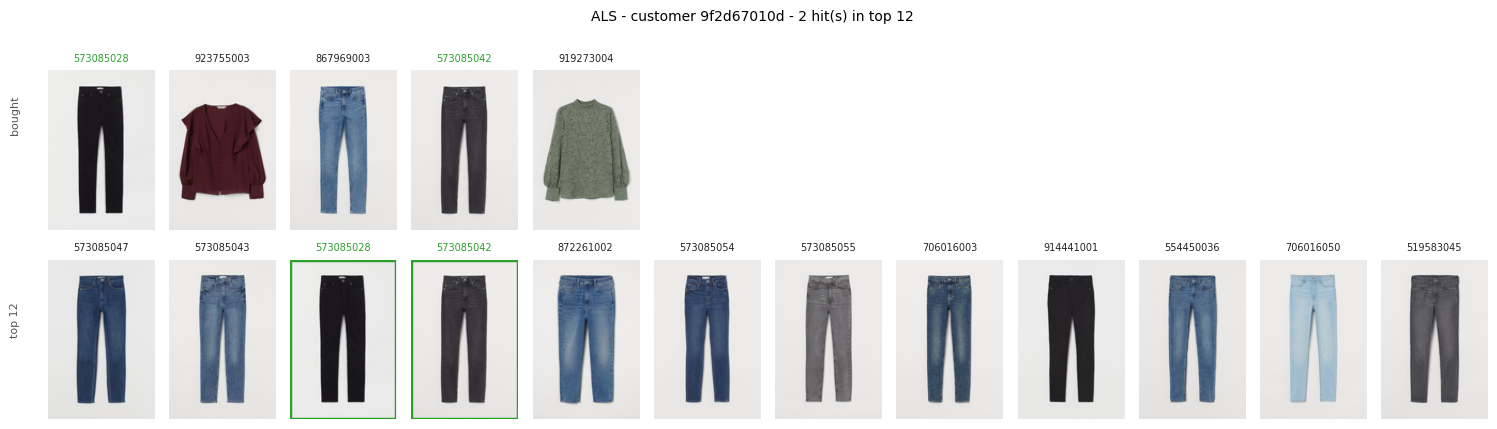

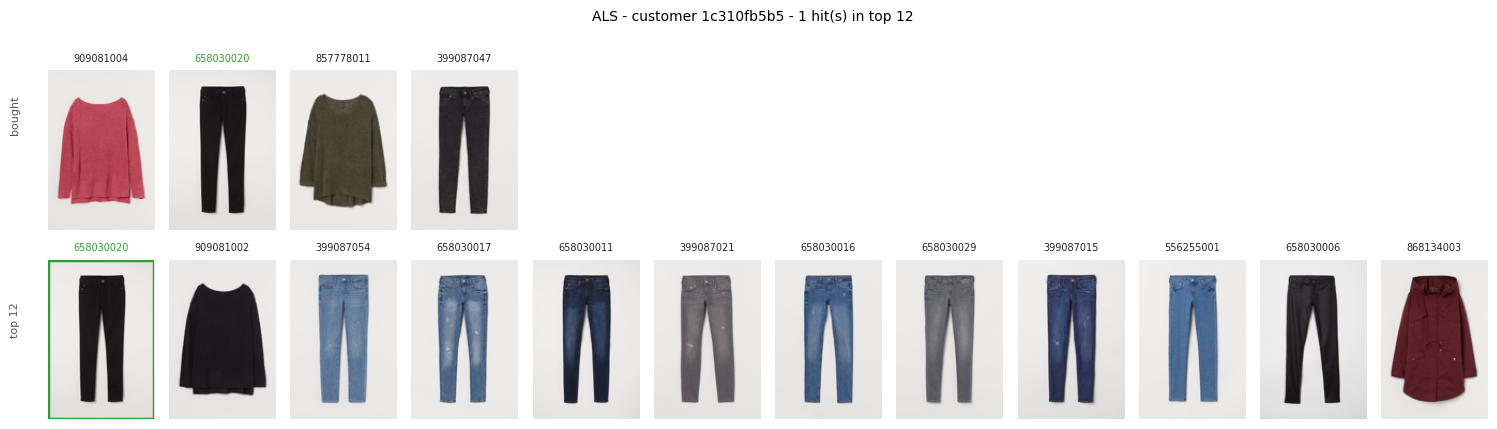

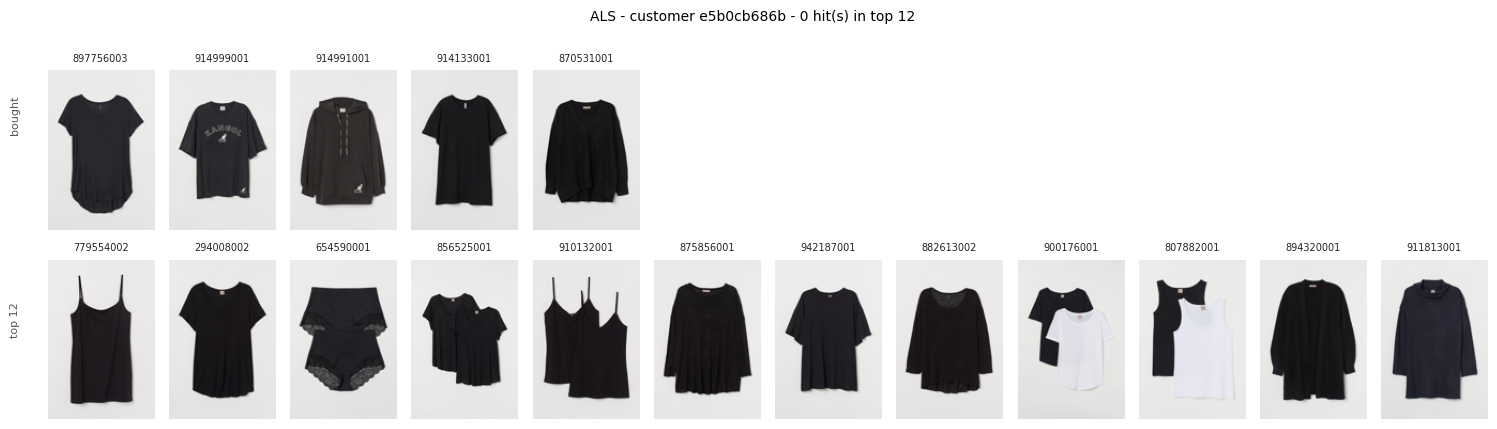

In [20]:
fitting_matrix, fitting_items, fitting_index = als.build_matrix(fitting_split)
als_model, als_weighted = als.fit(fitting_matrix)
als_predictions = als.recommend(als_model, als_weighted, test_truth, fitting_items, fitting_index, bestsellers)
show_recommendations("ALS", als_predictions)

## 7. Model 3 — content-based

ALS knows nothing about what an article *is*. An item nobody has bought has no
column in the matrix, so it can never be recommended — and this catalog turns
over constantly: **12% of the articles bought in the test week had never been sold
before it**. They are invisible to model 2 by construction — no purchases means no
column in its matrix.

This model describes items instead of counting them. Each article becomes a
vector from three sources — categorical fields, TF-IDF over `detail_desc`, and
the cached image embedding. The sparse metadata blocks are reduced with SVD to a
dense block, and similarity is a blend of two cosines, metadata and image.

A customer is the recency-weighted average of the articles they bought;
recommendations are the catalog articles nearest that average. Since vectors come
from an article's own attributes, a never-purchased article still has one.

In [21]:
content = importlib.import_module("03_content_based")

catalog_ids = content.catalog(load_transactions())
metadata_block = content.metadata_features(catalog_ids)
image_block = content.image_features(catalog_ids, content.IMAGE_ENCODER)

cold_start_articles = set(catalog_ids) - set(fitting_split["article_id"].to_list())
print(f"candidate articles: {len(catalog_ids):,}  (ALS could only rank {len(item_ids):,})")
print(f"never bought in train+val: {len(cold_start_articles):,}")
print(f"metadata block {metadata_block.shape}, image block {image_block.shape}")

candidate articles: 28,086  (ALS could only rank 26,672)
never bought in train+val: 639
metadata block (28086, 128), image block (28086, 512)


How much does the photo actually add over the text and categories it already has?
Sweep the blend weight on the validation week, for both cached encoders. Weight 0
is metadata only, weight 1 is pixels only.

In [22]:
content_sweep = []
for encoder in ENCODERS:
    block = content.image_features(catalog_ids, encoder)
    profiles, profile_index = content.customer_profiles(train_split, catalog_ids, [metadata_block, block])
    for weight in (0.0, 0.25, 0.5, 0.75, 1.0):
        preds = content.recommend(profiles, [metadata_block, block], [1 - weight, weight], val_truth, profile_index, catalog_ids, bestsellers)
        scored = evaluate(preds, val_truth)
        content_sweep.append({"encoder": encoder, "image_weight": weight,
                              "val_map@12": round(scored["map@12"], 5), "val_recall@100": round(scored["recall@100"], 5)})

pl.DataFrame(content_sweep).sort("val_map@12", descending=True)

encoder,image_weight,val_map@12,val_recall@100
str,f64,f64,f64
"""clip""",0.5,0.01854,0.07097
"""clip""",0.75,0.01833,0.06918
"""resnet18""",0.75,0.01827,0.06552
"""resnet18""",0.5,0.01816,0.07024
"""clip""",0.25,0.0177,0.07091
"""resnet18""",0.25,0.01759,0.0698
"""resnet18""",0.0,0.0155,0.06856
"""clip""",0.0,0.0155,0.06856
"""clip""",1.0,0.0151,0.05924


In [23]:
content_scores = content.main()
metrics_table(content_scores)

03_content_based: 28,086 candidate articles (639 never sold before the test week)
  cold-start articles surfaced in a top-12: 255
  @12   precision=0.00590  recall=0.03319  hitrate=0.06065  ndcg=0.02492  map=0.01833
  @50   precision=0.00256  recall=0.05383  hitrate=0.10181  ndcg=0.03054  map=0.01934
  @100  precision=0.00185  recall=0.07272  hitrate=0.14176  ndcg=0.03465  map=0.01967


metric,@12,@50,@100
str,f64,f64,f64
"""precision""",0.0059,0.00256,0.00185
"""recall""",0.03319,0.05383,0.07272
"""hitrate""",0.06065,0.10181,0.14176
"""ndcg""",0.02492,0.03054,0.03465
"""map""",0.01833,0.01934,0.01967


Below ALS overall — unsurprising, since knowing *who buys what* beats knowing
*what things look like* for customers with history. The point is what it reaches
that ALS cannot. Scoring both models against **only the cold-start purchases**
(test-week buys of articles never bought in training) makes the difference
concrete.

In [24]:
content_blocks = [metadata_block, image_block]
content_profiles, content_index = content.customer_profiles(fitting_split, catalog_ids, content_blocks)
content_predictions = content.recommend(
    content_profiles, content_blocks, [1 - content.IMAGE_WEIGHT, content.IMAGE_WEIGHT],
    test_truth, content_index, catalog_ids, bestsellers,
)

cold_truth = {c: [a for a in bought if a in cold_start_articles] for c, bought in test_truth.items()}
cold_truth = {c: bought for c, bought in cold_truth.items() if bought}

pl.DataFrame([
    {"model": name, "customers": scored["n_customers"],
     "cold_recall@12": round(scored["recall@12"], 5), "cold_recall@100": round(scored["recall@100"], 5),
     "cold_hitrate@100": round(scored["hitrate@100"], 5)}
    for name, scored in (
        ("02_collaborative_als", evaluate(als_predictions, cold_truth)),
        ("03_content_based", evaluate(content_predictions, cold_truth)),
    )
])

model,customers,cold_recall@12,cold_recall@100,cold_hitrate@100
str,i64,f64,f64,f64
"""02_collaborative_a…",893,0.0,0.0,0.0
"""03_content_based""",893,0.00653,0.02909,0.03695


ALS scores exactly zero on these — not a rounding artefact but a structural limit,
since an article with no purchases has no column in its matrix and therefore no
vector. The content model reaches them because its vectors come from an article's
own attributes, which exist before anybody buys anything. That is the signal model
3 adds, and the reason it belongs in the candidate pool for model 5 even though
its headline number sits below ALS.

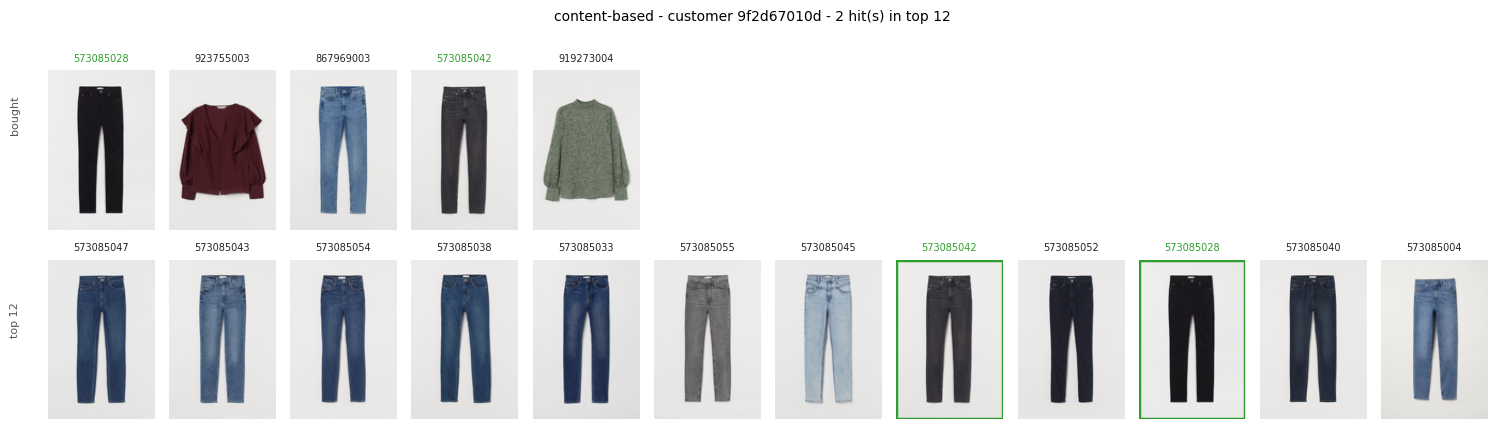

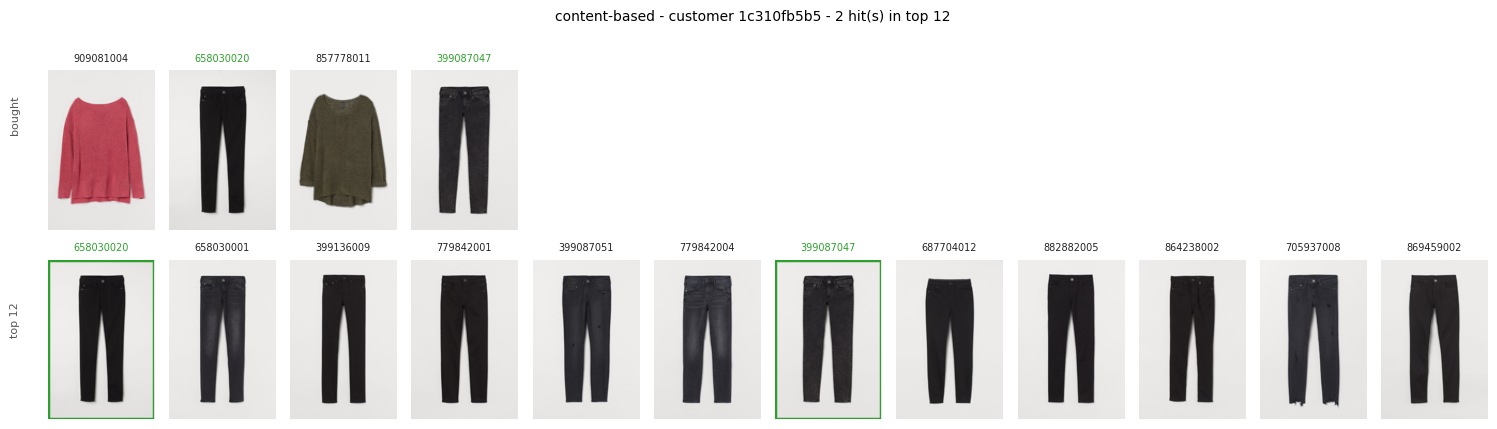

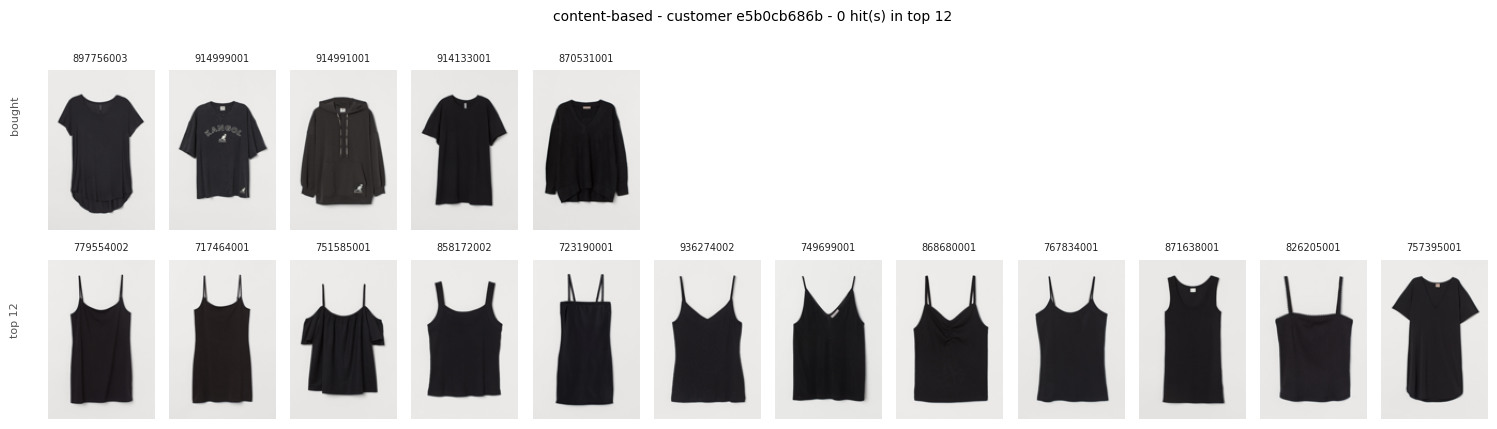

In [25]:
show_recommendations("content-based", content_predictions)

## 8. Model 4 — two-tower neural retrieval

Models 2 and 3 each use half the evidence. ALS sees co-purchase patterns and
nothing about the items; the content model sees the items and nothing about who
buys together. A two-tower network learns both at once — one tower turns a
customer into a vector, another turns an article into a vector, and training
pushes a customer's vector towards what they actually bought.

- **Item tower**: the same content features model 3 uses, *plus* a free per-article
  vector learned from the interactions. The learned part carries the collaborative
  signal; it stays at its zero initialisation for articles nobody bought, so those
  fall back to pure content and cold-start survives.
- **User tower**: the recency-weighted average of the customer's purchased
  articles, plus their own attributes (age, club status, news frequency).

Training uses **in-batch negatives** — within a batch of (customer, bought
article) pairs, every other customer's article counts as a negative, so one matrix
multiply supplies thousands of negatives for free.

One subtlety that decides whether this works at all: the user vector is an average
of purchased articles, so leaving the positive article inside that average lets the
model score it by recognising itself. Each pair subtracts its own article from the
average first.

In [26]:
two_tower = importlib.import_module("04_two_tower")
trained = two_tower.train_model(transactions=fitting_split, select_best=False)

  epoch  1  loss=8.0226


  epoch  2  loss=7.6355


  epoch  3  loss=7.4825


  epoch  4  loss=7.3864


  epoch  5  loss=7.3108


...

  epoch 16  loss=6.8831


  epoch 17  loss=6.8594


  epoch 18  loss=6.8369


  epoch 19  loss=6.8162


  epoch 20  loss=6.7955


The two settings that mattered, measured on the validation week with the model
fitted on train only, as tuning requires. Temperature is the biggest lever: at 0.05 the softmax is peaked enough that a few negatives dominate each
step. The learned item vector helps — but only at the lower learning rate; at 1e-3
it memorises instead, driving training loss down while validation gets worse.

In [27]:
tower_sweep = []
for use_embedding in (False, True):
    for temperature in (0.05, 0.15):
        probe = two_tower.train_model(verbose=False, epochs=20, learning_rate=3e-4,
                                      temperature=temperature, use_item_embedding=use_embedding)
        tower_sweep.append({"item_embedding": use_embedding, "temperature": temperature,
                            "best_val_map@12": round(probe["best_val_map"], 5)})
        del probe

pl.DataFrame(tower_sweep).sort("best_val_map@12", descending=True)

item_embedding,temperature,best_val_map@12
bool,f64,f64
true,0.15,0.01534
false,0.15,0.01333
false,0.05,0.01298
true,0.05,0.01264


In [28]:
tower_scores = two_tower.main()
metrics_table(tower_scores)

  epoch  1  loss=8.0237


  epoch  2  loss=7.6352


  epoch  3  loss=7.4814


  epoch  4  loss=7.3861


  epoch  5  loss=7.3103


...

  epoch 18  loss=6.8372


  epoch 19  loss=6.8168


  epoch 20  loss=6.7958


04_two_tower: fixed 20 epochs, refitted on train+val
  @12   precision=0.00644  recall=0.03484  hitrate=0.06546  ndcg=0.02366  map=0.01579
  @50   precision=0.00288  recall=0.05933  hitrate=0.10975  ndcg=0.03027  map=0.01698
  @100  precision=0.00205  recall=0.07986  hitrate=0.14874  ndcg=0.03471  map=0.01736


metric,@12,@50,@100
str,f64,f64,f64
"""precision""",0.00644,0.00288,0.00205
"""recall""",0.03484,0.05933,0.07986
"""hitrate""",0.06546,0.10975,0.14874
"""ndcg""",0.02366,0.03027,0.03471
"""map""",0.01579,0.01698,0.01736


Third among the personalised models on MAP@12 — the deep model lost to plain
matrix factorisation. That is a real result, not a bug to tune away: 309 K
interactions over 28 K articles is a small dataset for a neural retriever, and ALS
is very hard to beat at this scale.

But MAP@12 is the wrong lens for what this model is *for*. Compare the models on
**recall@100**, which is what a retrieval stage is judged on — how much of the
truth it puts anywhere in a candidate pool, leaving the ordering to a ranker:

In [29]:
pl.DataFrame([
    {"model": name, "map@12": round(scored["map@12"], 5), "recall@12": round(scored["recall@12"], 5),
     "recall@100": round(scored["recall@100"], 5)}
    for name, scored in (
        ("01_popularity", popularity_scores),
        ("02_collaborative_als", als_scores),
        ("03_content_based", content_scores),
        ("04_two_tower", tower_scores),
    )
]).sort("recall@100", descending=True)

model,map@12,recall@12,recall@100
str,f64,f64,f64
"""02_collaborative_a…",0.02434,0.05195,0.09462
"""04_two_tower""",0.01579,0.03484,0.07986
"""03_content_based""",0.01833,0.03319,0.07272
"""01_popularity""",0.0035,0.01146,0.04052


The two-tower ranks **last among the personalised models on MAP@12, yet its
recall@100 (0.081) beats the content model's (0.073)** — it reaches articles the
content model does not, and simply orders them worse. ALS leads on both.

That split — decent retrieval, weaker ordering — is why all of these feed the
candidate pool in model 5 rather than just the best-scoring one. A retriever earns
its place by finding things the others miss, not by ranking them correctly.

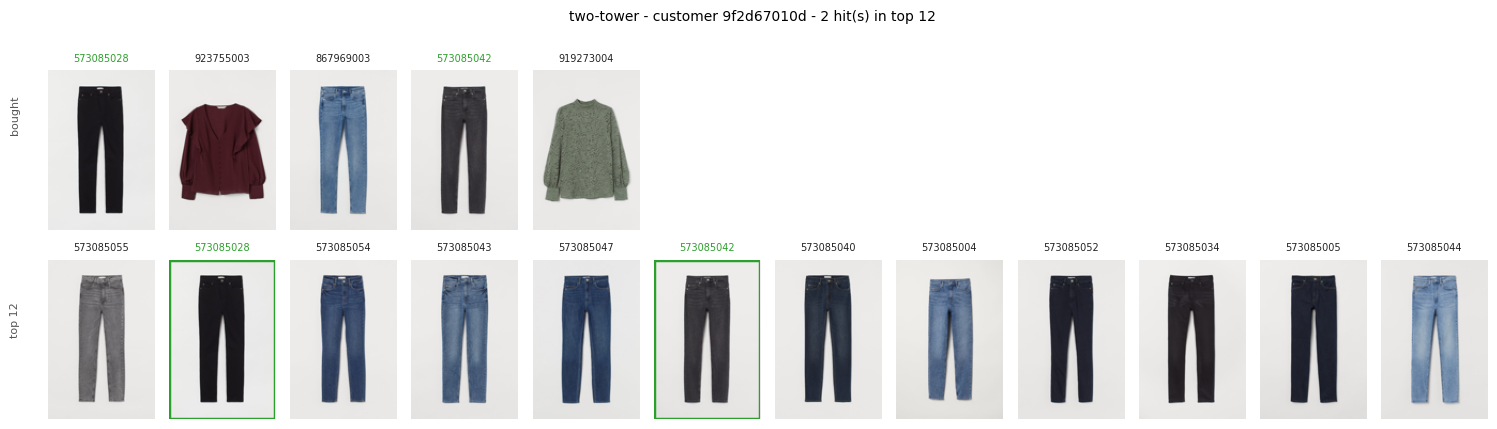

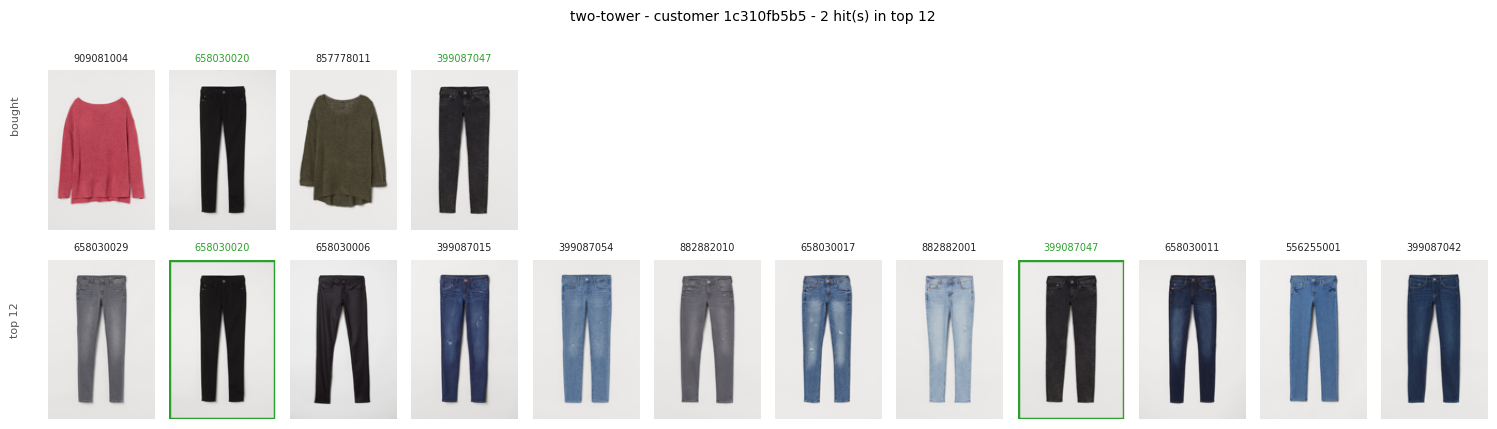

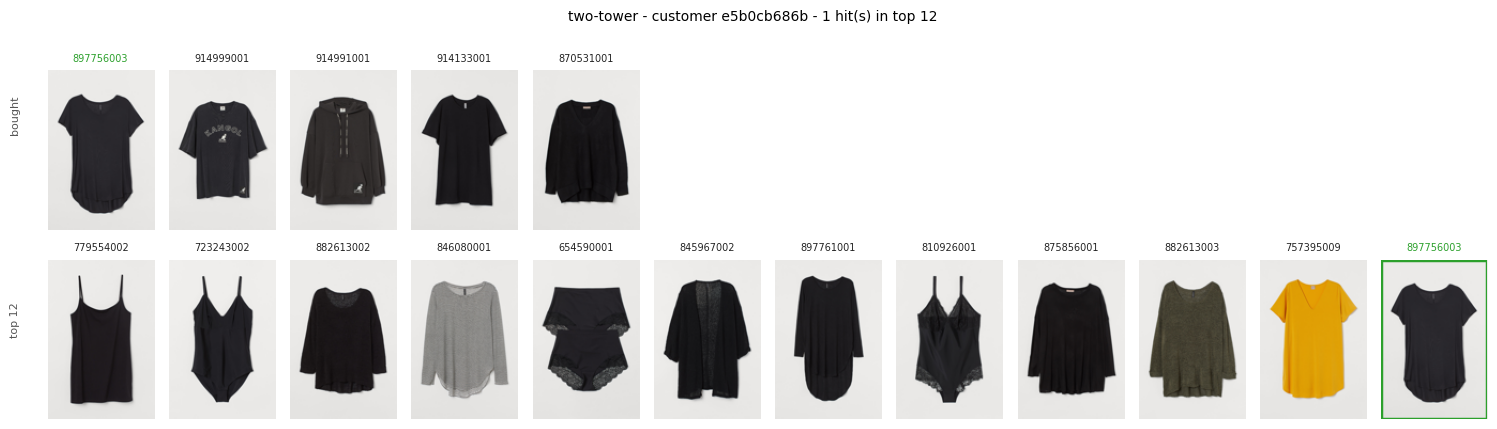

In [30]:
tower_predictions = two_tower.rank(
    trained["user_tower"], trained["item_tower"], trained["item_features"], test_truth,
    trained["customer_index"], trained["article_ids"], trained["history_sum"],
    trained["history_weight"], trained["static"], trained["fallback"], trained["device"],
)
show_recommendations("two-tower", tower_predictions)

## 9. Model 5 — two-stage: multi-recall + LightGBM ranker

Each of the four models is wrong in its own way: popularity ignores the person,
ALS ignores the item, content ignores co-purchase, the two-tower orders things
poorly. The winning Kaggle solutions did not pick one — they pooled candidates
from many cheap retrievers and trained a ranker to sort the pool.

**Stage one** is `src/retrievers.py`: a `Retriever` base class with six
implementations. Three wrap models 2–4; the other three are heuristics that cost
almost nothing and matter more than the models do:

| retriever | what it nominates |
|---|---|
| `RecentBestsellers` | what sold most in the last 7 days of the fitting window |
| `PreviousPurchases` | the customer's own articles, most recent first |
| `ColourVariants` | other colourways of what they bought (shared `product_code`) |

**Stage two** describes every (customer, candidate) pair with thirteen features —
each retriever's rank, how many nominated it, popularity, recency, repurchase
count, customer activity — and trains LightGBM's `lambdarank`.

Two details decide whether it works, and both were found the hard way:

- **Labels come from four weeks, not one**, on a rolling origin: each week's
  candidates come from retrievers refitted on data strictly *before* it. Refitting
  per week is the slow part and it is not optional — reusing one fitted model
  across the label weeks lets it nominate candidates informed by the very week it
  is being scored on.
- **Negatives are downsampled.** A full pool is 0.17% positives, and the ranker
  drowned in it: more trees scored *worse*. Keeping every positive plus 30
  negatives per customer cuts training rows 30x and scores better.

In [31]:
ranker = importlib.import_module("05_two_stage_ranker")
staged = ranker.run()
metrics_table(staged["scores"])

  label week -0: 4,383 customers, 2,291,530 pairs, 3,790 positives -> 71,890 training rows


  label week -1: 4,602 customers, 2,390,734 pairs, 4,110 positives -> 78,510 training rows


  label week -2: 4,936 customers, 2,547,579 pairs, 4,229 positives -> 80,489 training rows


  label week -3: 4,376 customers, 2,264,880 pairs, 3,433 positives -> 66,553 training rows


/home/sarthak/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


metric,@12,@50,@100
str,f64,f64,f64
"""precision""",0.01177,0.00589,0.00424
"""recall""",0.06243,0.11645,0.16061
"""hitrate""",0.11721,0.22696,0.31119
"""ndcg""",0.04137,0.05625,0.06574
"""map""",0.02732,0.02993,0.03072


What each retriever contributes on its own, as the recall ceiling it would give
if it were the only source. The cheap heuristics carry the pool.

In [32]:
staged["recall_by_retriever"]

retriever,k,ceiling
str,i64,f64
"""recent""",300,0.2231
"""als""",200,0.0833
"""tower""",200,0.0697
"""content""",200,0.0614
"""variant""",100,0.0505
"""repurchase""",50,0.0393


In [33]:
print(f"pool: {staged['test_pool'].height:,} pairs, {staged['test_pool'].height / staged['scores']['n_customers']:.0f} candidates per customer")
print(f"pool ceiling (oracle recall): {staged['ceiling']:.4f}   achieved recall@100: {staged['scores']['recall@100']:.4f}")
print(f"the ranker extracts {100 * staged['scores']['recall@100'] / staged['ceiling']:.0f}% of what the pool makes reachable")
staged["importance"]

pool: 2,181,859 pairs, 525 candidates per customer
pool ceiling (oracle recall): 0.3156   achieved recall@100: 0.1606
the ranker extracts 51% of what the pool makes reachable


feature,gain
str,i32
"""article_purchases""",2045
"""customer_purchases""",1730
"""rank_recent""",1040
"""article_days_since…",826
"""best_rank""",796
"""rank_als""",508
…,…
"""rank_tower""",434
"""rank_content""",375


**The bottleneck has moved.** An earlier version of this model pooled only the
four trained models, reaching a ceiling of 0.085 — and the ranker extracted 97% of
it, so ranking was saturated and recall was the constraint. With the heuristic
retrievers added the ceiling is now about 0.32 and the ranker reaches roughly half
of it. Recall is no longer what limits this system; ordering is. That is a better
problem to have, and it points at richer ranker features rather than more
candidates.

**The most useful features are still not the model ranks.** Article purchase
count, customer activity and recency outrank every retriever's opinion. The
retriever ranks matter as a committee — `n_sources` and `best_rank`, how many
models agreed and how strongly — more than as individual orderings.

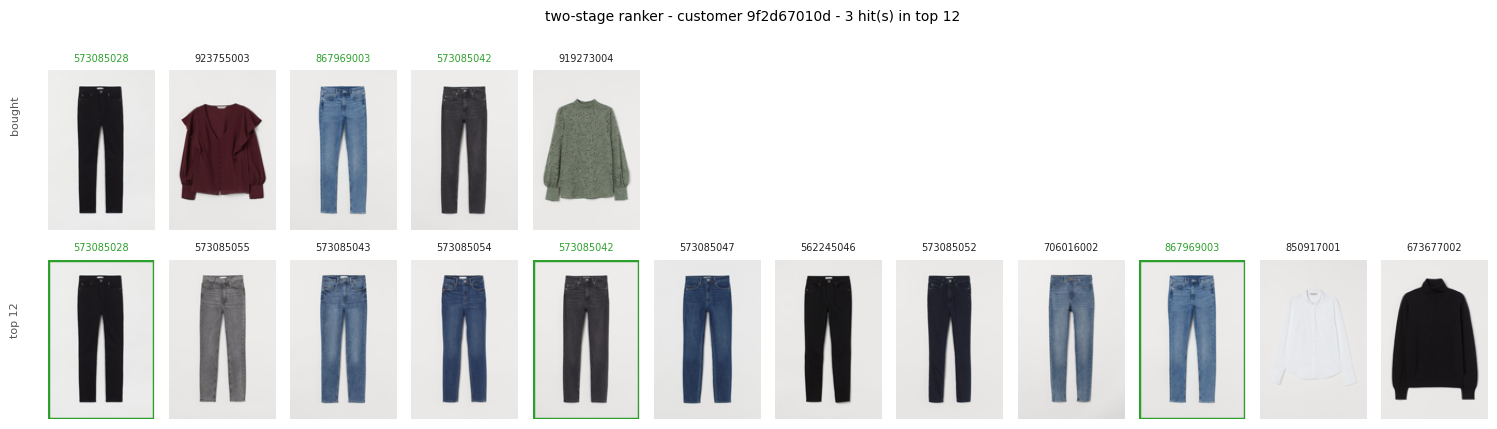

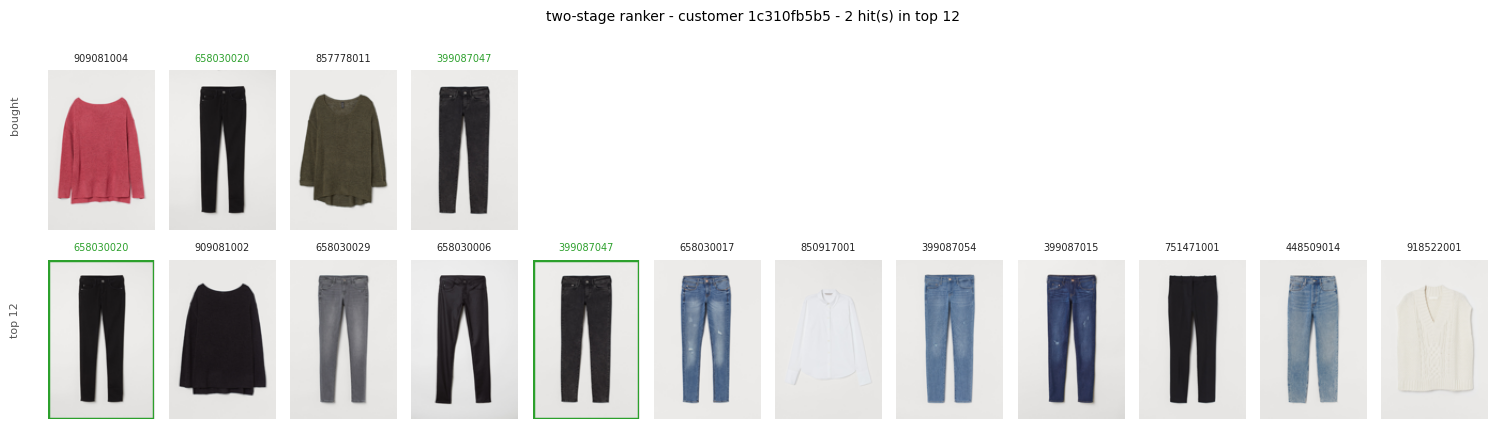

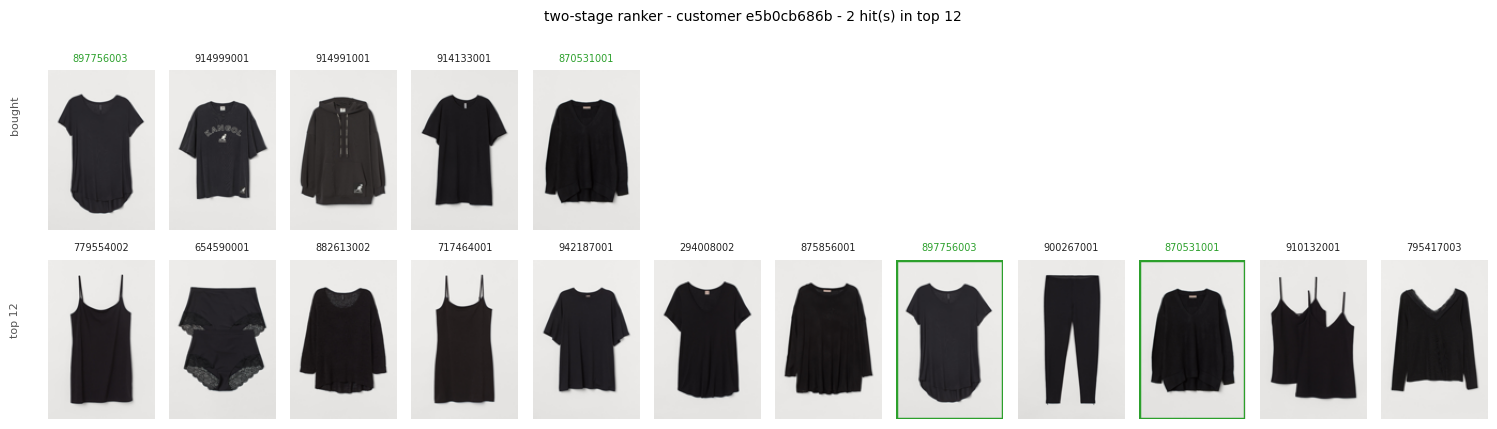

In [34]:
show_recommendations("two-stage ranker", staged["predictions"])

## 10. Final comparison

All five models, same test week, same metrics module, one row each.

In [35]:
comparison = pl.read_csv(ROOT / "results" / "metrics_comparison.csv").sort("model")

with pl.Config(fmt_str_lengths=40, tbl_width_chars=400, tbl_cols=20):
    for k in KS:
        print(f"@{k}")
        display(comparison.select(["model"] + [f"{metric}@{k}" for metric in ("precision", "recall", "hitrate", "ndcg", "map")]))

@12


model,precision@12,recall@12,hitrate@12,ndcg@12,map@12
str,f64,f64,f64,f64,f64
"""01_popularity""",0.002828,0.011458,0.03201,0.007155,0.0035
"""02_collaborative_als""",0.009587,0.051955,0.093381,0.035471,0.024336
"""03_content_based""",0.005897,0.033189,0.06065,0.024918,0.018333
"""04_two_tower""",0.006438,0.034842,0.065463,0.023664,0.015785
"""05_two_stage_ranker""",0.011773,0.06243,0.117208,0.041368,0.027322


@50


model,precision@50,recall@50,hitrate@50,ndcg@50,map@50
str,f64,f64,f64,f64,f64
"""01_popularity""",0.00142,0.023446,0.06426,0.01045,0.003959
"""02_collaborative_als""",0.00375,0.076028,0.143201,0.042223,0.025553
"""03_content_based""",0.002561,0.053826,0.101805,0.030535,0.019344
"""04_two_tower""",0.002883,0.059326,0.109747,0.03027,0.016984
"""05_two_stage_ranker""",0.005887,0.116453,0.226955,0.056247,0.029927


@100


model,precision@100,recall@100,hitrate@100,ndcg@100,map@100
str,f64,f64,f64,f64,f64
"""01_popularity""",0.001261,0.040524,0.106859,0.014275,0.00424
"""02_collaborative_als""",0.00238,0.094622,0.177858,0.046109,0.025873
"""03_content_based""",0.001848,0.072716,0.141757,0.034655,0.019668
"""04_two_tower""",0.002053,0.079864,0.148736,0.034709,0.017363
"""05_two_stage_ranker""",0.004238,0.160615,0.311191,0.065739,0.030716


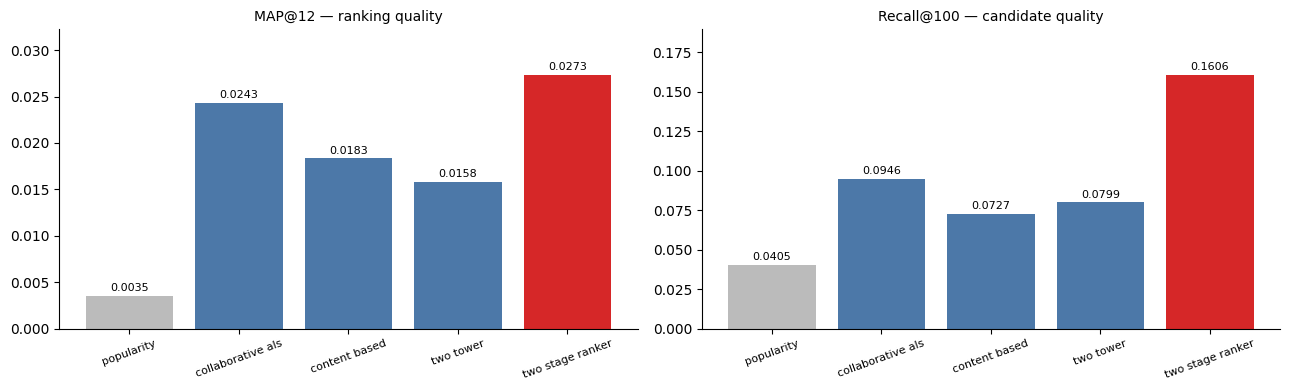

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels = [m.split("_", 1)[1].replace("_", " ") for m in comparison["model"]]
for ax, metric, title in zip(axes, ("map@12", "recall@100"), ("MAP@12 — ranking quality", "Recall@100 — candidate quality")):
    values = comparison[metric].to_list()
    bars = ax.bar(labels, values, color=["#bbb", "#4c78a8", "#4c78a8", "#4c78a8", "#d62728"])
    ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, max(values) * 1.18)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The progression holds: every model beats the non-personalised floor, and the
two-stage system beats every single-model approach on both axes.

The absolute numbers stay low, and that is the honest shape of this problem — the
Kaggle winner scored 0.0372 MAP@12 on the full dataset with a hundred-plus-feature
ranker over a multi-strategy recall ensemble. Two-thirds of a test week's
purchases are of articles the customer never bought before, from a catalog that
turns over weekly, and most customers buy two or three things. The point of this
notebook is the progression and the evaluation, not the leaderboard.